# Clasificadores generativos: Inferencia bayesiana

Los clasificadores **discriminativos** como el clasificador geométrico por mínimos cuadrados que vimos la clase pasada, se enfocan en modelar la frontera de decisión. Recordemos que una frontera de decisión lineal está dada por:
\begin{equation}
\boldsymbol{w}^T \boldsymbol{x} = 0
\end{equation}
y el entrenamiento del clasificador se reduce a encontrar los valores del vector $\boldsymbol{w}$ que separen correctamente los datos de entrenamiento.


Existe otro enfoque para el aprendizaje que consiste en no modelar la frontera de decisión directamente, sino en construir un modelo para los datos de cada una de las clases y permitir que la frontera de decisión aparezca naturalmente. Este tipo de clasificador se denomina **generativo**.

Una forma de modelar los datos consiste en utilizar modelos probabilísticos. Para esto, supondremos que los datos tienen una función de densidad de probabilidad en particular, que nos permita realizar inferencias basándonos en el teorema de Bayes:

\begin{equation}
p(y|x) = \frac{p(x|y)p(y)}{p(x)}
\end{equation}

En esta ecuación, cada uno de los elementos que intervienen tienen un nombre específico:

\begin{equation}
posterior = \frac{(verosimilutud)(prior)}{evidencia}
\end{equation}

Consideremos un ejemplo:

## Consideremos un ejemplo:

Supongamos que un banco utiliza un sistema de Inteligencia Artificial para detectar transacciones fraudulentas.

Sabemos lo siguiente:

- Solo el 0.5% de las transacciones son fraudulentas.
- El sistema tiene una sensibilidad del 99% (detecta correctamente el 99% de los fraudes).
- El sistema tiene una especificidad del 99% (clasifica correctamente como normales el 99% de las transacciones legítimas).

Si el sistema marca una transacción como fraudulenta, ¿cuál es la probabilidad real de que efectivamente sea fraude?

---

En este problema tenemos dos variables aleatorias (las llamamos aleatorias porque tienen incertidumbre asociada):

\begin{equation}
\text{transacción} =
\begin{cases}
F & \text{fraude} \\
N & \text{normal}
\end{cases}
\end{equation}

\begin{equation}
\text{modelo} =
\begin{cases}
+ & \text{marcada como fraude} \\
- & \text{marcada como normal}
\end{cases}
\end{equation}

Estamos interesados en conocer:

\begin{equation}
p(\text{transacción}=F \mid \text{modelo}=+)
\end{equation}

Simplificando, usamos la notación:

\begin{equation}
p(F|+)
\end{equation}

Aplicamos el teorema de Bayes:

\begin{equation}
p(F|+) = \frac{p(+|F)p(F)}{p(+)}
\end{equation}

---

### Prior

A $ p(F) $ lo llamamos **prior** y representa nuestro conocimiento antes de observar el resultado del modelo.

Sabemos que sólo el 0.5% de las transacciones son fraudulentas:

\begin{equation}
p(F) = 0.005
\end{equation}

Por lo tanto:

\begin{equation}
p(N) = 1 - 0.005 = 0.995
\end{equation}

Esto quiere decir que, a priori, es extremadamente probable que cualquier transacción sea normal.

---

### Verosimilitud

A $ p(+|F) $ lo llamamos **verosimilitud** y nos dice qué tan creíble es el modelo cuando realmente hay fraude.

Como el modelo tiene una sensibilidad del 99%:

\begin{equation}
p(+|F) = 0.99
\end{equation}

También sabemos que la especificidad es 99%, es decir:

\begin{equation}
p(-|N) = 0.99
\end{equation}

Por lo tanto, la probabilidad de que el modelo cometa un falso positivo es:

\begin{equation}
p(+|N) = 1 - 0.99 = 0.01
\end{equation}

---

### Evidencia

A $ p(+) $ lo llamamos **evidencia** y representa la probabilidad total de que el modelo marque una transacción como fraudulenta, sin saber aún si realmente lo es.

Usamos la ley de probabilidad total:

\begin{equation}
p(+) = p(+|F)p(F) + p(+|N)p(N)
\end{equation}

\begin{equation}
p(+) = (0.99)(0.005) + (0.01)(0.995)
\end{equation}

\begin{equation}
p(+) = 0.00495 + 0.00995
\end{equation}

\begin{equation}
p(+) = 0.0149
\end{equation}

Observemos que, aunque el modelo es muy preciso, la mayoría de las alertas provienen de transacciones normales, simplemente porque son muchísimas más.

---

### Posterior

Finalmente, calculamos el **posterior**:

\begin{equation}
p(F|+) = \frac{p(+|F)p(F)}{p(+)}
\end{equation}

\begin{equation}
p(F|+) = \frac{0.99(0.005)}{0.0149}
\end{equation}

\begin{equation}
p(F|+) = \frac{0.00495}{0.0149}
\end{equation}

\begin{equation}
p(F|+) = 0.332
\end{equation}

---

## Resultado

\begin{equation}
p(F|+) \approx 0.33
\end{equation}

Así que, incluso cuando el modelo tiene 99% de sensibilidad y 99% de especificidad, si marca una transacción como fraude, solo hay aproximadamente un **33% de probabilidad real** de que efectivamente sea fraude.

Este resultado muestra cómo, cuando la prevalencia de un evento es muy baja, los falsos positivos pueden dominar el resultado final.


¿Cómo usamos este método de inferencia para entrenar un clasificador?

Reescribimos el teorema de Bayes en función de las muestras y las clases:

\begin{equation}
p(clase=c_i|muestra = \boldsymbol{x}) = \frac{p(muestra = \boldsymbol{x}|clase=c_i)p(clase=c_i)}{p(muestra=\boldsymbol{x})}
\end{equation}

Nuevamente simplificando la notación:

\begin{equation}
p(c_i|\boldsymbol{x}) = \frac{p(\boldsymbol{x}|c_i)p(c_i)}{p(\boldsymbol{x})}
\end{equation}

Entonces lo que hacemos es iterar por todas las clases y encontrar la probabilidad más alta. Suponiendo que la única característica de nuestras muestras ($\boldsymbol{x}$) sea el color, podríamos tener algo como:

\begin{equation}
p(limón|verde) = \frac{p(verde|limón)p(limón)}{p(verde)}
\end{equation}

\begin{equation}
p(naranja|verde) = \frac{p(verde|naranja)p(naranja)}{p(verde)}
\end{equation}

\begin{equation}
p(manzana|verde) = \frac{p(verde|manzana)p(manzana)}{p(verde)}
\end{equation}

¿Cuál será la maś alta? Es importante notar que el denominador es el mismo en todos los casos, así que desde el punto de vista de clasificación, nos podemos quedar sólo con el numerador.

Ahora, cuando no tenemos valores discretos sino continuos, lo que hacemos para definir la verosimilitud es escoger una función de densidad de probabilidad. Lo más usual es utilizar la función de probabilidad Gaussiana:

\begin{equation}
p(\boldsymbol{x}|c_i) = \frac{1}{\sqrt{(2\pi)^k |\Sigma_i|}}e^{-\frac{1}{2}(\boldsymbol{x}-\boldsymbol{\mu}_i)^T \Sigma_i^{-1}(\boldsymbol{x}-\boldsymbol{\mu}_i)}
\end{equation}

donde $\boldsymbol{\mu}_i$ es la media de la clase $c_i$ y $\Sigma_i$ es la matriz de covarianza de esa clase.

Consideremos nuevamente la base de datos Iris, tomando solamente dos clases:

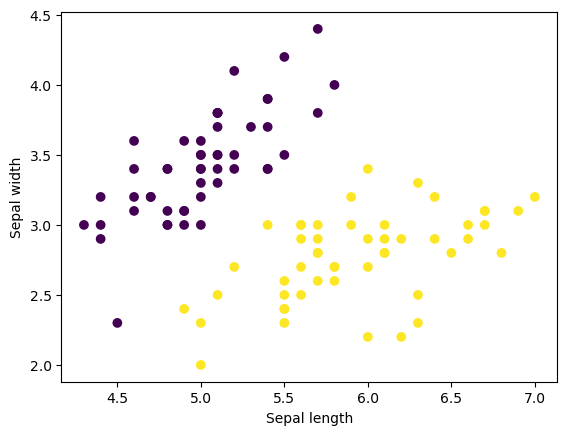

In [1]:
import matplotlib.pyplot as plt
from sklearn import datasets
# Importamos la base de datos iris
iris = datasets.load_iris()
X = iris.data[0:100:, :2]  # Tomamos las dos primeras características (150 muestras, 2 características)
y = iris.target[0:100]
plt.scatter(X[:, 0], X[:, 1],c=y)
plt.xlabel('Sepal length')
plt.ylabel('Sepal width')
plt.show()

Veamos cuál es la media de cada clase:

In [2]:
import numpy as np
setosa=np.array(X[0:50,:]);
versicolor=np.array(X[50:100,:]);
print(np.mean(setosa,axis=0))
print(np.mean(versicolor,axis=0))

[5.006 3.428]
[5.936 2.77 ]


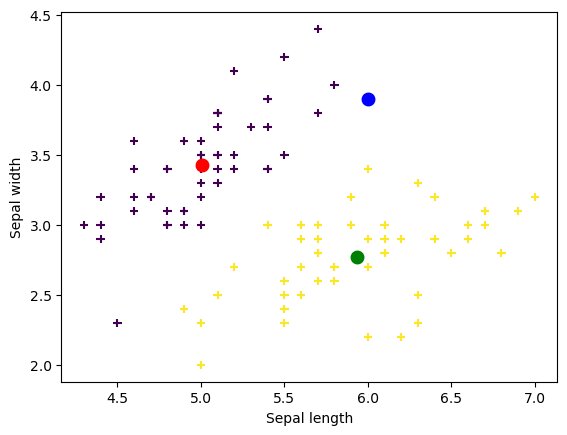

[[0.12424898 0.09921633]
 [0.09921633 0.1436898 ]]


In [8]:
plt.scatter(X[:, 0], X[:, 1],c=y,marker='+')
plt.xlabel('Sepal length')
plt.ylabel('Sepal width')
plt.scatter(5.006,3.428,c='red',marker='o',linewidths=4)
plt.scatter(5.936,2.77,c='green',marker='o',linewidths=4)
plt.scatter(6.0,3.9,c='blue',marker='o',linewidths=4)
plt.show()
cset=np.cov(np.transpose(setosa))
print(cset)

Ahora veamos cómo sería el entrenamiento:

In [9]:
mset=np.mean(setosa,axis=0) #Medias
mver=np.mean(versicolor,axis=0)
cset=np.cov(np.transpose(setosa)) #Matrices de covarianza. Transponemos la matriz porque numpy espera las variables en las columnas
cver=np.cov(np.transpose(versicolor))
campana_set=lambda x:(1/(np.sqrt(((2*np.pi)**2)*np.linalg.det(cset))))* (np.exp(-1/2*((x-mset).dot(np.linalg.inv(cset))).dot(np.transpose(x-mset)))) 
campana_ver=lambda x:(1/(np.sqrt(((2*np.pi)**2)*np.linalg.det(cver))))* (np.exp(-1/2*((x-mver).dot(np.linalg.inv(cver))).dot(np.transpose(x-mver)))) 
#Hasta aquí llega el entrenamiento
prueba=np.array([6.0,3.9])
print(campana_set(prueba))
print(campana_ver(prueba))

0.014946983264982176
0.00020258425034948502


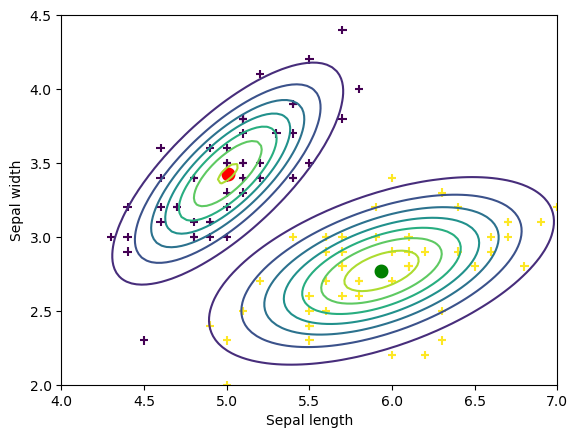

In [6]:
#Veamos las campanas gaussianas
x1, x2 = np.meshgrid(np.linspace(4,7,100),np.linspace(2,4.5,100))
gauss_set = np.zeros(shape=(len(x1),len(x2)))
gauss_ver = np.zeros(shape=(len(x1),len(x2)))
for i in range(len(x1)):
    for j in range(len(x2)):
        x=np.array([x1[i,j],x2[i,j]])
        gauss_set[i,j]=campana_set(x)
        gauss_ver[i,j]=campana_ver(x)

plt.scatter(X[:, 0], X[:, 1],c=y,marker='+')
plt.xlabel('Sepal length')
plt.ylabel('Sepal width')
h1 = plt.contour(x1,x2,gauss_set)
h2 = plt.contour(x1,x2,gauss_ver)
plt.scatter(5.006,3.428,c='red',marker='o',linewidths=4)
plt.scatter(5.936,2.77,c='green',marker='o',linewidths=4)



¿Y cómo se hace en sklearn?
Se importa el clasificador Gaussian Naive Bayes 

In [ ]:
from sklearn.naive_bayes import GaussianNB
clf = GaussianNB()
clf.fit(X, y)
test=np.array([[4.5,2.3]]) #Prueba
clf.predict(test)

La inferencia bayesiana también se puede usar para definir explícitamente una forntera de decisión. Consideremos que queremos obtener una función de la forma:

\begin{equation}
f(\boldsymbol{x}) = \boldsymbol{w}^T \boldsymbol{x}
\end{equation}

a partir de una serie de etiquetas $y_i$, $i \in 1\ldots N$. La tarea de un algoritmo de de clasificación es entonces encontrar los pesos $\boldsymbol{w}$ que **con mayor probabilidad** puedan haber generado las etiquetas $y_i$.

Diremos que estos puntos son producto de la función más una cantidad de variables que desconocemos y que podemos resumir en un error aleatorio:

\begin{equation}
y_i = \boldsymbol{w}^T \boldsymbol{x}_i +\varepsilon_i
\end{equation}

donde supondremos una función de densidad de probabilidad para este error, que generalmente es gaussiana con media cero y varianza $\sigma^2$, esto es, $\varepsilon_i \sim  \mathcal{N}(0,\,\sigma^{2})$. La probabilidad de $y_i$ tendrá entonces también distribución gaussiana pero centrada en $\boldsymbol{w}^T \boldsymbol{x}_i$:

\begin{equation}
\varepsilon_i \sim   \mathcal{N}(0,\,\sigma^{2}) = \frac{1}{\sqrt{2\pi \sigma^2}} e^{-\frac{\varepsilon_i^2}{2\sigma^2}} 
\end{equation}

\begin{equation}
y_i \sim  \mathcal{N}(\boldsymbol{w}^T \boldsymbol{x}_i ,\sigma^{2}) = \frac{1}{\sqrt{2\pi \sigma^2}} e^{-\frac{(y_i - \boldsymbol{w}^T \boldsymbol{x}_i)^2 }{2\sigma^2}} 
\end{equation}

Si suponemos que estos errores son independientes e idénticamente distribuidos (i.i.d.), la función de densidad de probabilidad de la variable $y$ será entonces la multiplicación de la probabilidad de todos los $y_i$:

\begin{equation}
\begin{array}{r,l}
p(\boldsymbol{y} | \boldsymbol{w},\boldsymbol{X}) &= \prod_{i=1}^N \frac{1}{\sqrt{2\pi \sigma^2}} e^{-\frac{(y_i - \boldsymbol{w}^T \boldsymbol{x}_i)^2 }{2\sigma^2} } \\
& = \frac{1}{(2\pi \sigma^2)^{N/2}} e^{-\sum_{i=1}^{N}\frac{(y_i - \boldsymbol{w}^T \boldsymbol{x}_i)^2 }{2\sigma^2} } 
\end{array}
\end{equation}

o matricialmente:

\begin{equation}
p(\boldsymbol{y} | \boldsymbol{w},\boldsymbol{X}) =  \frac{1}{(2\pi \sigma^2)^{N/2}} e^{-\frac{1}{2\sigma^2}(\boldsymbol{y} - \boldsymbol{w}^T\boldsymbol{X})^T(\boldsymbol{y} - \boldsymbol{w}^T\boldsymbol{X}) } 
\end{equation}

Esta densidad de probabilidad de $\boldsymbol{y}$ nos sive como verosimilitud en el teorema de Bayes, con el fin de encontrar el valor más probable de $\boldsymbol{w}$:

\begin{equation}
p(\boldsymbol{w}|\boldsymbol{y},\boldsymbol{X}) = \frac{p(\boldsymbol{y}|\boldsymbol{w},\boldsymbol{X})p(\boldsymbol{w})}{p(\boldsymbol{y}|\boldsymbol{X})}
\end{equation}

## Estimación de máxima verosimilitud

Ahora debemos hacer una suposición acerca de el *prior* $p(\boldsymbol{w})$. La primera opción consiste en suponer que $p(\boldsymbol{w})$ es uniforme (que todos los valores de $\boldsymbol{w}$ son igualmente probables, con lo cual, maximizar $p(\boldsymbol{w}|\boldsymbol{y},\boldsymbol{x})$ equivale a maximizar la verosimilitud $p(\boldsymbol{y}|\boldsymbol{w},\boldsymbol{x})$ (porque el denominador no depende de $\boldsymbol{w}$ y el prior se vuelve constante). Entonces el problema de encontrar $\boldsymbol{w}$ se convierte en:

\begin{equation}
\boldsymbol{w}_{mle} = \underset{\boldsymbol{w}}{\operatorname{argmax}}p(\boldsymbol{y}|\boldsymbol{w},\boldsymbol{X}) 
\end{equation}

Para hacer más fácil este procedimiento, podemos usar la log-verosimilitud (el máximos de $log(a)$ es el mismo de $a$):

\begin{equation}
\begin{array}{rl}
\mathcal{L}(\boldsymbol{w,\sigma^2}) & \equiv \operatorname{log}\left(p(\boldsymbol{y}|\boldsymbol{w},\boldsymbol{X}) \right)\\
& = -\frac{N}{2}\operatorname{log}(2\pi\sigma^2)-\frac{1}{2\sigma^2}\sum_{i=1}^{N}(y_i - \boldsymbol{w}^T\boldsymbol{x}_i)^2
\end{array}
\end{equation}

Para encontrar el máximo, entonces derivamos respecto a $\boldsymbol{w}$, igualamos a cero y despejamos:

\begin{equation}
\frac{\partial \mathcal{L}(\boldsymbol{w,\sigma^2})}{\partial \boldsymbol{w}} = \frac{1}{\sigma^2}\sum_{i=1}^{N}(y_i - \boldsymbol{w}^T\boldsymbol{x}_i)\boldsymbol{x}^T_i
\end{equation}

Igualando a cero y poniéndolo en notación matricial:

\begin{equation}
\begin{array}{rl}
\frac{1}{\sigma^2} (\boldsymbol{y} - \boldsymbol{X}^T\boldsymbol{w}_{mle})^T\boldsymbol{X}^T & = 0\\
\boldsymbol{y}^T\boldsymbol{X}^T - \boldsymbol{w}_{mle}^T\boldsymbol{X}\boldsymbol{X}^T & =0\\
\boldsymbol{w}_{mle} & = \left(\boldsymbol{X}\boldsymbol{X}^T\right)^{-1}\boldsymbol{X}\boldsymbol{y} \\
\end{array}
\end{equation}

\begin{equation}
\sum_{i=1}^N a_i x_i = \boldsymbol{a}^T \boldsymbol{x}
\end{equation}

Que se conoce como la *estimación de máxima verosimilitud* y que termina siendo igual a la regresión lineal por mínimos cuadrados. Es interesante ver además que si derivamos respecto a $\sigma^2$, obtendremos la ecuación de la varianza:

\begin{equation}
\frac{\partial \mathcal{L}(\boldsymbol{w},\sigma^2)}{\partial \boldsymbol{\sigma^2}} = -\frac{N}{2\sigma^2}+\frac{1}{2(\sigma^2)^2}\sum_{i=1}^{N}(y_i - \boldsymbol{w}^T\boldsymbol{x}_i)^2 = 0
\end{equation}

Luego:

\begin{equation}
\sigma^2 = \frac{1}{N}\sum_{i=1}^{N}(y_i - \boldsymbol{w}^T\boldsymbol{x}_i)^2
\end{equation}


## Estimación máximo a posteriori

Para hacer un modelo más robusto, podemos hacer una suposición diferente acerca del *prior* $p(\boldsymbol{w})$. En los procesos gaussianos este prior tiene densidad de probabilidad gaussiana con media cero y matriz de covarianza $\Sigma_p$ (como $\boldsymbol{w}$ es multidimensional, ya no hablamos de una desviación estándar $\sigma$ sino de una matriz de covarianza).

\begin{equation}
p(\boldsymbol{w}) \sim  \mathcal{N}(0,\Sigma_p)
\end{equation}

Entonces tenemos, usando el teorema de Bayes:

\begin{equation}
\begin{array}{rl}
p(\boldsymbol{w} | \boldsymbol{y},\boldsymbol{X}) & \propto p(\boldsymbol{y}|\boldsymbol{w},\boldsymbol{X})p(\boldsymbol{w}) \\
&\propto \frac{1}{(2\pi \sigma^2)^{N/2}} e^{-\frac{1}{2\sigma^2}(\boldsymbol{y} - \boldsymbol{w}^T\boldsymbol{X})^T(\boldsymbol{y} - \boldsymbol{w}^T\boldsymbol{X}) }  \frac{1}{(2\pi)^{N/2} |\Sigma_p|^{1/2}} e^{-\frac{1}{2}\boldsymbol{w}^T \Sigma_p^{-1} \boldsymbol{w} }
\end{array}
\end{equation}

Haciendo el producto y completando el cuadrado, tendremos:
\begin{equation}
p(\boldsymbol{w} | \boldsymbol{y},\boldsymbol{X}) \propto e^{-\frac{1}{2}(\boldsymbol{w} - \bar{\boldsymbol{w}})^T \boldsymbol{A} (\boldsymbol{w} - \bar{\boldsymbol{w}})}
\end{equation}

donde:
\begin{equation}
\boldsymbol{A} = \frac{1}{\sigma^2}\boldsymbol{X}\boldsymbol{X}^T + \Sigma_p^{-1}
\end{equation}

\begin{equation}
\boldsymbol{\bar{\boldsymbol{w}}} = \frac{1}{\sigma^2}\left(\frac{\boldsymbol{X}\boldsymbol{X}^T}{\sigma^2} + \Sigma_p^{-1}\right)^{-1}\boldsymbol{X}\boldsymbol{y}
\end{equation}

Esta estimación se denomina *maximum a posteriori* $\boldsymbol{w}_{MAP} \equiv \bar{\boldsymbol{w}}$:

\begin{equation}
\boldsymbol{\bar{\boldsymbol{w}}} = \frac{1}{\sigma^2}\boldsymbol{A}^{-1}\boldsymbol{X}\boldsymbol{y}
\end{equation}

Esta estimación también se conoce como *Ridge regression* en el caso en que $\Sigma_p = k\boldsymbol{I}$, es decir, que cada peso tenga una varianza igual a $1/k$, donde $k$ es un parámetro libre que debe ser sintonizado por el usuario.  